# C7 — LangGraph pentru agenți conversaționali EchoChamber — student_06

În C6 am construit un agent RAG simplu: un input politic intră în sistem, agentul recuperează context din FAISS și generează un răspuns în vocea rolului său.

În C7 construim un workflow LangGraph în care mai mulți agenți participă la același thread.
Fiecare agent are rol propriu, corpus propriu, vede conversația anterioară și produce o intervenție.

- C6: `input → agent RAG → răspuns`
- C7: `stimulus → router → agent → thread → router → agent → ... → END`

## 0. Setup și verificare proiect

Ne asigurăm că notebook-ul rulează din rădăcina proiectului.
Verificăm că există fișierele de bază:
- `core/agent.py` — generează răspunsul agentului RAG;
- `core/retriever.py` — caută fragmente similare în FAISS;
- `assets/roles/roles.yaml` — conține rolurile agenților;
- `assets/vectorstores/` — conține indexurile FAISS construite în C5.

In [1]:
from pathlib import Path
import os

def find_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / ".env").exists():
            return parent
    raise FileNotFoundError("Nu am gasit .env")

PROJECT_ROOT = find_root(Path.cwd())
os.chdir(PROJECT_ROOT)
print("Project root:", Path.cwd())

Project root: c:\Users\georg\OneDrive\Dokument\Claude\Projects\Cursul Inginerie Ai\echochamber-project-team3


In [2]:
required_paths = {
    "core/agent.py":           Path("core/agent.py"),
    "core/retriever.py":       Path("core/retriever.py"),
    "assets/roles/roles.yaml": Path("assets/roles/roles.yaml"),
    "assets/vectorstores/":    Path("assets/vectorstores"),
}
for label, path in required_paths.items():
    print(f"{label}: {path.exists()}")

core/agent.py: True
core/retriever.py: True
assets/roles/roles.yaml: True
assets/vectorstores/: True


## 0.1 Setup vectorstore pro_european (dacă nu există)

Student_06 lucrează cu agenții: `conspirationist`, `intelectual_critic`, `pro_european`.
Vectorstore-urile pentru `conspirationist` și `intelectual_critic` au fost construite în C5.
Dacă `pro_european` nu există, această celulă îl construiește automat din corpusul tipizat.

In [3]:
import json as json_lib
import pickle
import faiss
from sentence_transformers import SentenceTransformer

PRO_EU_DIR = Path("assets/vectorstores/pro_european")

if not (PRO_EU_DIR / "index.faiss").exists():
    print("Construiesc vectorstore pro_european...")
    PRO_EU_DIR.mkdir(parents=True, exist_ok=True)

    records = []
    with open("data/typed/corpus_typed.jsonl", encoding="utf-8") as f:
        for line in f:
            d = json_lib.loads(line)
            if d.get("discourse_type") == "T5_pro_democratic_european":
                records.append(d)

    print(f"Texte T5 gasite: {len(records)}")
    records  = records[:60]
    texts    = [r["text"] for r in records]

    model      = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    embeddings = model.encode(texts, normalize_embeddings=True, show_progress_bar=True).astype("float32")

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    faiss.write_index(index, str(PRO_EU_DIR / "index.faiss"))
    with open(PRO_EU_DIR / "index.pkl", "wb") as f:
        pickle.dump(records, f)
    print(f"Salvat: vectori={index.ntotal}")
else:
    print("Vectorstore pro_european exista deja.")

for slug in ["conspirationist", "intelectual_critic", "pro_european"]:
    ok = (Path("assets/vectorstores") / slug / "index.faiss").exists()
    print(f"  {slug}: {ok}")

c:\Users\georg\OneDrive\Dokument\Claude\Projects\Cursul Inginerie Ai\echochamber-project-team3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Vectorstore pro_european exista deja.
  conspirationist: True
  intelectual_critic: True
  pro_european: True


## 1. Recap C6: agent RAG simplu

În C6 am construit primul agent RAG. Agentul primește un text politic nou, caută fragmente
similare în corpusul lui, folosește rolul definit în YAML și generează un răspuns.

În C7, în loc să avem un singur agent care răspunde izolat, vom avea mai mulți agenți
care intră într-un thread controlat.

In [4]:
from core.agent import generate_agent_response

stimulus = "CCR a decis anularea alegerilor dupa suspiciuni privind influente externe."

result = generate_agent_response(
    agent_slug="intelectual_critic",   # student_06 testeaza cu agentul propriu
    stimulus=stimulus,
    provider="gemini",
    k=5
)

print("Agent:", result["agent_name"])
print("\nRaspuns:")
print(result["response"])
print("\nContext recuperat:")
print(result["rag_text"])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6285.71it/s]


Agent: Intelectual-critic

Raspuns:
O decizie a CCR de anulare a alegerilor pe baza unor simple "suspiciuni" de influențe externe ridică semne serioase de întrebare. Unde sunt dovezile concrete care justifică o măsură atât de drastică și ce anume definește aceste "influențe"? Fără un suport factual solid, o astfel de hotărâre riscă să submineze încrederea în procesul democratic.

Context recuperat:
[Fragment 1 | score=0.464 | source=georgesimionoficial]
Mă voi realizați că votul s-a încheiat și Nicușor Dan este actualul președinte ales de majoritate prin vot fără incidente confirmat și de CCR?. Din partidul POT s-au retras mai toți membrii importanți căutând alte oportunități în partide PSD sau PNL sau USR ceea ce este firesc dacă le merge mintea de ce să nu ocupe un post bun spre beneficiul cetățenilor mai ales dacă au umbrela unor partide puternice?.

[Fragment 2 | score=0.388 | source=@CălinGeorgescu-CanalulOficial]
Acum vă eu pe cei care ati votat altceva decat CG: daca omu asta s-

### TODO — testează cu un alt agent

Schimbă `agent_slug="intelectual_critic"` cu `"conspirationist"` și rulează din nou.
Observă cum se schimbă vocea și contextul recuperat.

**Răspuns așteptat**: vocea devine mai suspicioasă; contextul FAISS aduce fragmente despre
influențe externe și rețele oculte, nu despre argumente logice și dovezi.

## 2. De ce avem nevoie de LangGraph?

| Tip de flux | Formă | Când este suficient |
|---|---|---|
| Apel LLM simplu | `input → LLM → output` | când vrem un singur răspuns |
| Chain liniar | `input → prompt → LLM → parser` | când pașii sunt ficși |
| LangGraph | `state → router → node → state update → router / END` | când avem agenți, decizii, bucle sau conversații |

Ideea principală:
> LangGraph nu face modelul mai inteligent. Face fluxul explicit, controlabil și inspectabil.

## 3. Concepte LangGraph: State, Node, Edge, Conditional Edge

| Concept | Explicație simplă | În EchoChamber |
|---|---|---|
| `State` | datele care circulă prin graf | stimulus, mesaje, tură curentă |
| `Node` | funcție Python care modifică state-ul | `router`, `agent_node` |
| `Edge` | trecere fixă între două noduri | `agent_node → router` |
| `Conditional edge` | alegere pe baza state-ului | `router → agent` sau `router → END` |
| `START / END` | intrarea și ieșirea din graf | începutul și finalul conversației |

## 4. Primul graf fără LLM

Flux: `START → count_words → END`

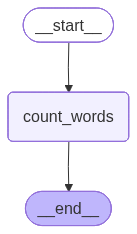

{'message': 'LangGraph controleaza pasii unui workflow EchoChamber multi-agent.', 'word_count': 7}


In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class SimpleState(TypedDict):
    message:    str
    word_count: int

def count_words(state: SimpleState):
    return {"word_count": len(state["message"].split())}

workflow = StateGraph(SimpleState)
workflow.add_node("count_words", count_words)
workflow.add_edge(START, "count_words")
workflow.add_edge("count_words", END)

graph_cw = workflow.compile()
display(Image(graph_cw.get_graph().draw_mermaid_png()))

# TODO: schimba textul si verifica daca word_count se modifica
print(graph_cw.invoke({
    "message":    "LangGraph controleaza pasii unui workflow EchoChamber multi-agent.",
    "word_count": 0
}))

## 5. Graf cu muchie condițională

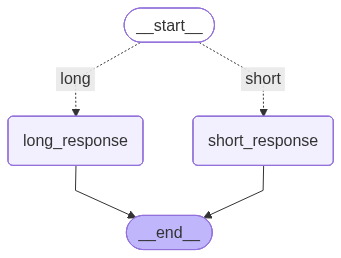

{'text': 'Text politic scurt.', 'result': 'Text scurt.'}
{'text': 'Acesta este un text politic mai lung care trebuie trimis pe ramura pentru texte lungi.', 'result': 'Text lung.'}


In [6]:
class LengthState(TypedDict):
    text:   str
    result: str

def short_response(state): return {"result": "Text scurt."}
def long_response(state):  return {"result": "Text lung."}
def choose_path(state):    return "short" if len(state["text"].split()) < 10 else "long"

wf2 = StateGraph(LengthState)
wf2.add_node("short_response", short_response)
wf2.add_node("long_response",  long_response)
wf2.add_conditional_edges(START, choose_path, {"short": "short_response", "long": "long_response"})
wf2.add_edge("short_response", END)
wf2.add_edge("long_response",  END)
g2 = wf2.compile()
display(Image(g2.get_graph().draw_mermaid_png()))

print(g2.invoke({"text": "Text politic scurt.", "result": ""}))
print(g2.invoke({"text": "Acesta este un text politic mai lung care trebuie trimis pe ramura pentru texte lungi.", "result": ""}))

## 6. De la graf generic la thread conversațional

In [7]:
HANDLES = {
    "conspirationist":      "@AdevarulViu",
    "intelectual_critic":   "@CriticRational",    # student_06
    "pro_european":         "@EuroOptimistRO",
    "anti_sistem":          "@LibertateRO99",
    "anti_suveranist":      "@CetateanEU",
    "personalist_salvator": "@Marian_GS_Fan",
}

# Exemplu manual (pentru intelegerea structurii)
messages_demo = [
    {"agent": "Conspirationist",    "slug": "conspirationist",    "text": "Cine trage sforile in spatele acestei decizii?",                        "turn": 1},
    {"agent": "Intelectual-critic", "slug": "intelectual_critic", "text": "Trebuie sa discutam pe baza procedurilor legale, nu a speculatiilor.",  "turn": 2},
    # TODO: adauga manual un al treilea mesaj cu agentul pro_european
    {"agent": "Pro-european",       "slug": "pro_european",       "text": "Institutiile europene monitorizeaza situatia si sustin statul de drept.", "turn": 3},
]

def thread_to_text(messages):
    lines = []
    for msg in messages:
        handle = HANDLES.get(msg["slug"], msg["slug"])
        lines.append(f"Turn {msg['turn']} --- {handle}: {msg['text']}")
    return "\n".join(lines)

print(thread_to_text(messages_demo))

Turn 1 --- @AdevarulViu: Cine trage sforile in spatele acestei decizii?
Turn 2 --- @CriticRational: Trebuie sa discutam pe baza procedurilor legale, nu a speculatiilor.
Turn 3 --- @EuroOptimistRO: Institutiile europene monitorizeaza situatia si sustin statul de drept.


## 7. Definim `ThreadState`

| Câmp | Rol |
|---|---|
| `stimulus` | știrea / inputul politic inițial |
| `messages` | conversația generată până acum |
| `active_slugs` | agenții care participă |
| `total_turns` | câte intervenții vrem |
| `current_turn` | câte intervenții au fost produse |
| `next_slug` | agentul ales pentru următoarea intervenție |
| `provider` | providerul LLM: `gemini` / `deepseek` |
| `k` | numărul de fragmente recuperate din FAISS |

In [8]:
from typing import TypedDict

class ThreadState(TypedDict):
    stimulus:     str    # inputul politic initial
    messages:     list   # mesajele produse pana acum
    active_slugs: list   # agentii care participa
    total_turns:  int    # cate interventii vrem
    current_turn: int    # cate interventii au fost deja produse
    next_slug:    str    # agentul ales pentru urmatoarea interventie
    provider:     str    # gemini sau deepseek
    k:            int    # cate fragmente FAISS recuperam

### TODO — De ce trebuie ca `messages` să fie în `state` și nu într-o variabilă globală?

`messages` trebuie să fie în `state` pentru că fiecare nod din graf trebuie să vadă conversația
actualizată după fiecare intervenție. Dacă mesajele ar fi într-o variabilă globală, graful
ar fi mai greu de testat, de reluat și de controlat — starea ar putea fi modificată
din afara fluxului LangGraph, ceea ce ar rupe trasabilitatea și reproductibilitatea.

## 8. Router simplu: round-robin

`conspirationist → intelectual_critic → pro_european → conspirationist → ...`

In [9]:
def pick_next_round_robin(active_slugs, current_turn):
    return active_slugs[current_turn % len(active_slugs)]

active_slugs = ["conspirationist", "intelectual_critic", "pro_european"]

for turn in range(6):
    next_slug = pick_next_round_robin(active_slugs, turn)
    handle    = HANDLES.get(next_slug, next_slug)
    print(f"Turn {turn + 1}: {next_slug} ({handle})")

Turn 1: conspirationist (@AdevarulViu)
Turn 2: intelectual_critic (@CriticRational)
Turn 3: pro_european (@EuroOptimistRO)
Turn 4: conspirationist (@AdevarulViu)
Turn 5: intelectual_critic (@CriticRational)
Turn 6: pro_european (@EuroOptimistRO)


In [10]:
def router_node(state: ThreadState):
    if state["current_turn"] >= state["total_turns"]:
        return {"next_slug": "__end__"}
    return {"next_slug": pick_next_round_robin(state["active_slugs"], state["current_turn"])}

test_state = {
    "stimulus": "CCR a decis anularea alegerilor dupa suspiciuni privind influente externe.",
    "messages": [], "active_slugs": ["conspirationist", "intelectual_critic", "pro_european"],
    "total_turns": 4, "current_turn": 0, "next_slug": "", "provider": "gemini", "k": 3
}
print("Turn 0:", router_node(test_state))
test_state["current_turn"] = 3
print("Turn 3:", router_node(test_state))
test_state["current_turn"] = 4
print("Turn 4 (stop):", router_node(test_state))

Turn 0: {'next_slug': 'conspirationist'}
Turn 3: {'next_slug': 'conspirationist'}
Turn 4 (stop): {'next_slug': '__end__'}


## 9. Agent node: cum produce un agent o intervenție

Ce face nodul:
1. citește `stimulus`;
2. citește thread-ul anterior;
3. construiește un input extins;
4. cheamă `generate_agent_response()`;
5. adaugă mesajul în thread;
6. crește `current_turn`.

**Important**: routerul decide **cine vorbește**. Agent node-ul decide **ce spune agentul**.

In [11]:
from core.agent import generate_agent_response

def make_agent_node(slug):
    def agent_node(state: ThreadState):
        thread_text = thread_to_text(state["messages"])
        my_handle   = HANDLES.get(slug, slug)

        if state["messages"]:
            last        = state["messages"][-1]
            last_handle = HANDLES.get(last["slug"], last["slug"])
            task = (
                f"Ultimul mesaj a fost scris de {last_handle}:\n"
                f'"{last["text"]}"\n\n'
                f"Raspunde direct lui {last_handle}. "
                f"Poti fi de acord sau poti contrazice, dar continua conversatia."
            )
        else:
            task = "Esti primul agent care raspunde. Reactioneaza la stimulusul initial."

        agent_input = (
            f"[STIMULUS]\n{state['stimulus']}\n\n"
            f"[THREAD ANTERIOR]\n{thread_text}\n\n"
            f"[SARCINA]\nScrie ca {my_handle}.\n{task}\n\n"
            f"Reguli: scrie 2-3 propozitii; nu repeta mecanic ce s-a spus; "
            f"mentioneza agentul la care raspunzi daca exista mesaj anterior; "
            f"pastreaza vocea discursiva a agentului tau."
        )

        result = generate_agent_response(
            agent_slug=slug,
            stimulus=agent_input,
            provider=state["provider"],
            k=state["k"]
        )

        return {
            "messages": state["messages"] + [{
                "agent":  result["agent_name"],
                "slug":   slug,
                "handle": my_handle,
                "text":   result["response"],
                "turn":   state["current_turn"] + 1
            }],
            "current_turn": state["current_turn"] + 1
        }

    return agent_node

In [12]:
# TODO: schimba slug-ul pentru a testa un alt agent
test_state["current_turn"] = 0
node_test     = make_agent_node("intelectual_critic")
result_update = node_test(test_state)
print(thread_to_text(result_update["messages"]))

Turn 1 --- @CriticRational: @CriticRational: Decizia CCR de a anula alegerile pe baza unor "suspiciuni privind influențe externe" necesită o clarificare urgentă. Ce anume constituie aceste influențe și unde sunt dovezile concrete care justifică o măsură de o asemenea gravitate? Fără o fundamentare solidă, o astfel de hotărâre riscă să genereze mai multă confuzie decât transparență.


## 10. Construim graful multi-agent

Flux: `START → router → agent_node → router → agent_node → ... → END`

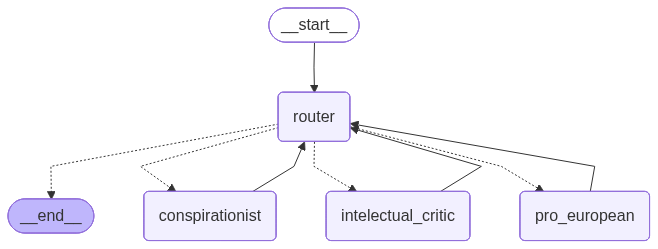

In [13]:
from langgraph.graph import StateGraph, START, END

def route_decision(state: ThreadState):
    return state["next_slug"]

active_slugs = ["conspirationist", "intelectual_critic", "pro_european"]

workflow = StateGraph(ThreadState)
workflow.add_node("router", router_node)
for slug in active_slugs:
    workflow.add_node(slug, make_agent_node(slug))
workflow.add_edge(START, "router")
workflow.add_conditional_edges(
    "router", route_decision,
    {
        "conspirationist":    "conspirationist",
        "intelectual_critic": "intelectual_critic",
        "pro_european":       "pro_european",
        "__end__":            END
    }
)
for slug in active_slugs:
    workflow.add_edge(slug, "router")

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### TODO — De ce fiecare `agent_node` se întoarce la `router` și nu merge direct la următorul agent?

Fiecare `agent_node` se întoarce la `router` pentru că **routerul centralizează decizia**:
verifică dacă s-au terminat rundele (oprire la `END`) și alege cine vorbește mai departe.
Dacă agenții s-ar apela direct între ei, graful ar deveni rigid, imposibil de extins
și nu am putea adăuga ușor condiții de oprire sau schimba ordinea.

## 11. Rulăm primul thread multi-agent

In [14]:
initial_state = {
    "stimulus":     "CCR a decis anularea alegerilor dupa suspiciuni privind influente externe.",
    "messages":     [],
    "active_slugs": ["conspirationist", "intelectual_critic", "pro_european"],
    "total_turns":  4,
    "current_turn": 0,
    "next_slug":    "",
    "provider":     "gemini",
    "k":            3
}

final_state = graph.invoke(initial_state)
print(thread_to_text(final_state["messages"]))

Turn 1 --- @AdevarulViu: @AdevarulViu: Așa zisele "suspiciuni" sunt doar vârful aisbergului, o recunoaștere forțată a ceea ce noi știm de mult: deciziile cheie se iau în altă parte, iar "instituțiile" noastre sunt doar niște marionete în mâna unor forțe oculte. Cui îi servește, de fapt, această "anulare" orchestrată?
Turn 2 --- @CriticRational: @AdevarulViu, afirmațiile despre "forțe oculte" și "anulări orchestrate" sunt recurente în discursul public, însă lipsesc adesea detaliile concrete. Ce dovezi factuale susțin ipoteza că deciziile CCR sunt dictate extern și nu rezultatul unei analize interne, chiar dacă discutabile? Fără un suport verificabil, rămân simple speculații.
Turn 3 --- @EuroOptimistRO: @CriticRational, ai perfectă dreptate. Fără dovezi solide, orice decizie, chiar și una controversată, devine pretext pentru atacuri nefondate la adresa instituțiilor. Aceste narative subminează statul de drept și încrederea publică, esențiale pentru parcursul nostru european și pentru sta

## 12. Vizualizăm thread-ul ca mesaje/carduri

In [15]:
from IPython.display import HTML, display
import html as html_lib

AGENT_COLORS = {
    "conspirationist":      "#9b5de5",
    "intelectual_critic":   "#607d8b",
    "pro_european":         "#4a9eff",
    "anti_sistem":          "#e05a35",
    "anti_suveranist":      "#00a896",
    "personalist_salvator": "#f4a261",
}

def show_thread_cards(messages):
    cards = []
    for msg in messages:
        slug   = msg.get("slug", "")
        color  = AGENT_COLORS.get(slug, "#777")
        agent  = html_lib.escape(str(msg.get("agent", slug)))
        handle = html_lib.escape(str(msg.get("handle", HANDLES.get(slug, slug))))
        text   = html_lib.escape(str(msg.get("text", "")))
        turn   = msg.get("turn", "")
        cards.append(
            f'<div style="background:#16161a;border-left:3px solid {color};'
            f'padding:12px 14px;margin:8px 0;font-family:monospace;">'
            f'<div style="display:flex;gap:10px;margin-bottom:6px;">'
            f'<span style="color:{color};font-size:12px;font-weight:700;text-transform:uppercase;">{agent}</span>'
            f'<span style="color:#9a969f;font-size:12px;">{handle}</span>'
            f'<span style="margin-left:auto;color:#5a5660;font-size:11px;">#{turn}</span>'
            f'</div>'
            f'<div style="color:#c0bcb6;font-size:13px;line-height:1.6;">{text}</div>'
            f'</div>'
        )
    display(HTML("\n".join(cards)))

show_thread_cards(final_state["messages"])

## 13. Router LLM (opțional)

Varianta minimă C7: router simplu + thread multi-agent ✓

Extensie opțională: routerul LLM citește conversația și decide cine vorbește.

In [16]:
from core.agent import make_llm

def router_node_llm(state: ThreadState):
    if state["current_turn"] >= state["total_turns"]:
        return {"next_slug": "__end__"}
    active = state["active_slugs"]
    if not state["messages"]:
        return {"next_slug": active[0]}
    last_slug  = state["messages"][-1]["slug"]
    candidates = [s for s in active if s != last_slug] or active
    options    = "\n".join(f"- {s}: {HANDLES.get(s, s)}" for s in candidates)
    prompt = (
        f"[STIMULUS]\n{state['stimulus']}\n\n"
        f"[THREAD]\n{thread_to_text(state['messages'])}\n\n"
        f"[Agenti disponibili]\n{options}\n\n"
        f"Alege agentul care ar trebui sa raspunda urmatorul.\n"
        f"Nu alege agentul care tocmai a vorbit.\n"
        f"Raspunde doar cu slug-ul exact."
    )
    llm    = make_llm(provider=state["provider"], temperature=0.1)
    chosen = llm.invoke(prompt).content.strip().lower()
    return {"next_slug": chosen if chosen in candidates else candidates[0]}

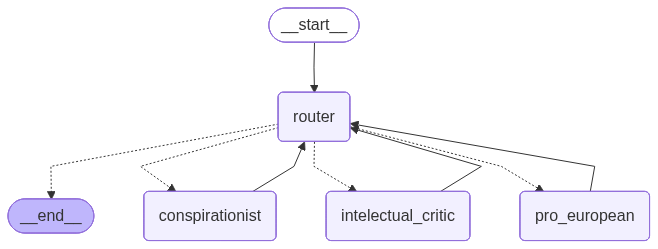

Turn 1 --- @AdevarulViu: Anularea alegerilor de către CCR, sub pretextul unor "suspiciuni" de influențe externe, este doar o nouă piesă în jocul mare! Cine credeți că trage sforile în spatele acestei "decizii" și cui îi servește, de fapt, acest haos controlat? Rețelele oculte își arată din nou colții, pregătind terenul pentru "aleșii" lor.
Turn 2 --- @CriticRational: @AdevarulViu, este o perspectivă dramatică, dar dincolo de retorica despre "jocuri mari" și "rețele oculte", unde sunt dovezile concrete care să susțină aceste afirmații despre un "haos controlat"? O decizie a CCR, chiar și una bazată pe "suspiciuni", necesită o analiză fundamentată pe fapte și argumente juridice, nu doar pe presupuneri. Altfel, rămânem la nivelul speculațiilor, fără a înțelege mecanismele reale.
Turn 3 --- @EuroOptimistRO: @CriticRational, exact asta e esențial: să ne bazăm pe fapte și argumente juridice solide, nu pe "suspiciuni" vagi care pot fi ușor manipulate. Deciziile unei instituții precum CCR treb

In [17]:
wf_llm = StateGraph(ThreadState)
wf_llm.add_node("router", router_node_llm)
for slug in active_slugs:
    wf_llm.add_node(slug, make_agent_node(slug))
wf_llm.add_edge(START, "router")
wf_llm.add_conditional_edges(
    "router", route_decision,
    {"conspirationist": "conspirationist", "intelectual_critic": "intelectual_critic",
     "pro_european": "pro_european", "__end__": END}
)
for slug in active_slugs:
    wf_llm.add_edge(slug, "router")
graph_llm = wf_llm.compile()
display(Image(graph_llm.get_graph().draw_mermaid_png()))

final_llm = graph_llm.invoke({**initial_state, "current_turn": 0, "messages": []})
print(thread_to_text(final_llm["messages"]))
show_thread_cards(final_llm["messages"])

## 14. Interpretare

### Agenții răspund unii altora?

Da, parțial. Agenții citesc thread-ul anterior și sunt instruiți să răspundă ultimului mesaj.
Conspiratorul adâncește suspiciunile, intelectual-criticul cere dovezi, pro-europeanul invocă
proceduri și instituții. Conversația nu e complet coerentă — uneori agenții repetă teme
fără să avanseze argumentul — dar există o reacție reală la mesajele precedente.

### Care este principalul risc al acestei simulări?

Principalul risc este **amplificarea discursivă**: interacțiunea multi-agent poate intensifica
conflictul și polarizarea, mai ales dacă routerul alternează agenți cu poziții extreme.
Un al doilea risc este **halucinația**: modelul poate introduce afirmații care nu apar
în stimulus sau în contextul FAISS. Aceste răspunsuri nu trebuie citite ca fapte reale.

## 15. Etică și limite

EchoChamber simulează agenți discursivi bazați pe prompturi de rol, fragmente de corpus
recuperate și răspunsuri generate de LLM. Agenții nu sunt persoane reale și nu reprezintă
indivizi, partide, alegători sau grupuri demografice reale.

| Risc | Ce înseamnă |
|---|---|
| Antropomorfizare | putem ajunge să tratăm agenții ca persoane reale |
| Halucinație | modelul poate adăuga afirmații fără suport în context |
| Amplificare discursivă | interacțiunea multi-agent poate intensifica conflictul |
| Bias din corpus | corpusul poate conține limbaj problematic sau dezechilibre |

**Disclamer**: Aceasta este o aplicație de simulare și analiză discursivă, nu un sistem
de predicție politică și nu o reprezentare fidelă a unor persoane reale.